
Computing NTK for width = 8

Computing NTK for width = 16

Computing NTK for width = 32

Computing NTK for width = 64


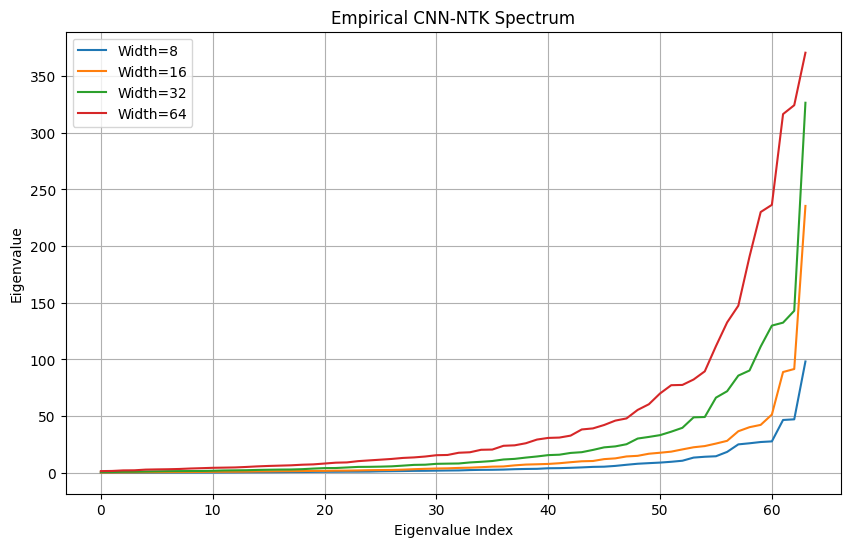

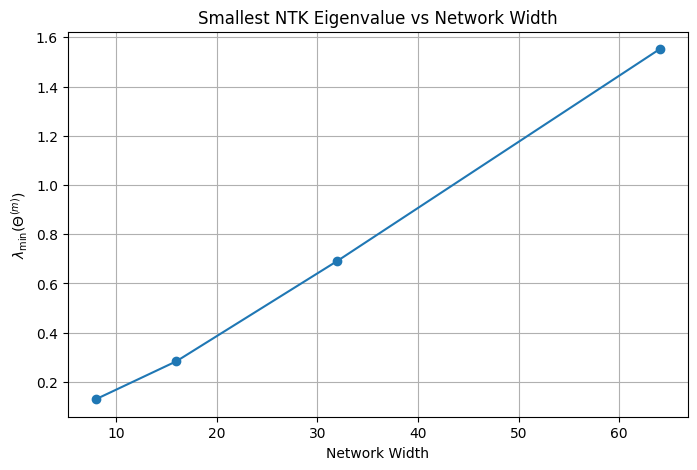

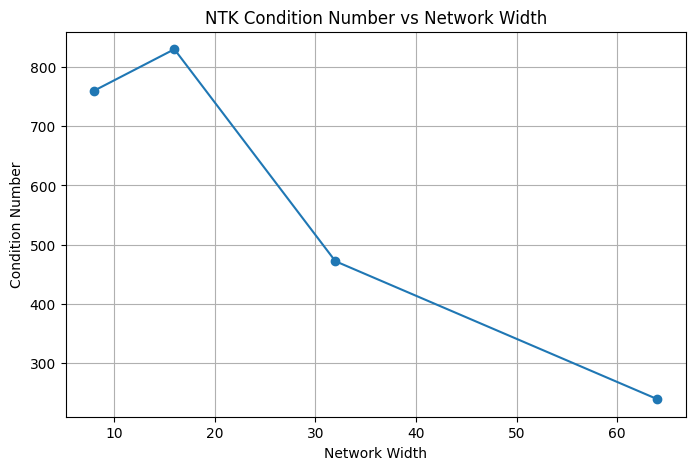


NTK Spectral Statistics
Width = 8
Smallest Eigenvalue = 1.292691e-01
Condition Number    = 7.599648e+02
------------------------------------------------
Width = 16
Smallest Eigenvalue = 2.835454e-01
Condition Number    = 8.302924e+02
------------------------------------------------
Width = 32
Smallest Eigenvalue = 6.915187e-01
Condition Number    = 4.720254e+02
------------------------------------------------
Width = 64
Smallest Eigenvalue = 1.551709e+00
Condition Number    = 2.387973e+02
------------------------------------------------


In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

# ============================================================
# DIP-style CNN
# ============================================================

class DIPNet(nn.Module):
    def __init__(self, width):
        super(DIPNet, self).__init__()

        self.net = nn.Sequential(
            nn.Conv2d(1, width, kernel_size=3, padding=1),
            nn.Tanh(),

            nn.Conv2d(width, width, kernel_size=3, padding=1),
            nn.Tanh(),

            nn.Conv2d(width, 1, kernel_size=3, padding=1)
        )

    def forward(self, x):
        return self.net(x)


# ============================================================
# Compute Empirical NTK
# ============================================================

def compute_ntk(model, x):

    model.zero_grad()

    output = model(x)

    output_flat = output.view(-1)

    n_outputs = output_flat.shape[0]

    params = [p for p in model.parameters() if p.requires_grad]

    total_params = sum(p.numel() for p in params)

    J = torch.zeros(n_outputs, total_params)

    for i in range(n_outputs):

        model.zero_grad()

        output_flat[i].backward(retain_graph=True)

        grad_list = []

        for p in params:
            grad_list.append(p.grad.view(-1))

        J[i] = torch.cat(grad_list)

    NTK = J @ J.t()

    return NTK.detach().cpu().numpy()


# ============================================================
# Widths to test
# ============================================================

widths = [8, 16, 32, 64]

min_eigs = []
cond_numbers = []

plt.figure(figsize=(10, 6))

# ============================================================
# Fixed random DIP input
# ============================================================

x = torch.randn(1, 1, 8, 8)

# ============================================================
# Run experiments
# ============================================================

for width in widths:

    print(f"\nComputing NTK for width = {width}")

    model = DIPNet(width)

    NTK = compute_ntk(model, x)

    eigvals = np.linalg.eigvalsh(NTK)

    eigvals = np.sort(eigvals)

    min_eig = eigvals[0]
    max_eig = eigvals[-1]

    condition_number = max_eig / (min_eig + 1e-12)

    min_eigs.append(min_eig)
    cond_numbers.append(condition_number)

    # Plot eigenvalue spectrum
    plt.plot(
        eigvals,
        label=f'Width={width}'
    )

# ============================================================
# Plot NTK spectra
# ============================================================

plt.title("Empirical CNN-NTK Spectrum")
plt.xlabel("Eigenvalue Index")
plt.ylabel("Eigenvalue")
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# Plot smallest eigenvalue vs width
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(widths, min_eigs, marker='o')

plt.title("Smallest NTK Eigenvalue vs Network Width")
plt.xlabel("Network Width")
plt.ylabel(r"$\lambda_{\min}(\Theta^{(m)})$")
plt.grid(True)
plt.show()

# ============================================================
# Plot condition number vs width
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(widths, cond_numbers, marker='o')

plt.title("NTK Condition Number vs Network Width")
plt.xlabel("Network Width")
plt.ylabel("Condition Number")
plt.grid(True)
plt.show()

# ============================================================
# Print numerical values
# ============================================================

print("\n================================================")
print("NTK Spectral Statistics")
print("================================================")

for i, width in enumerate(widths):

    print(f"Width = {width}")
    print(f"Smallest Eigenvalue = {min_eigs[i]:.6e}")
    print(f"Condition Number    = {cond_numbers[i]:.6e}")
    print("------------------------------------------------")